# СЕГМЕНТ 7: Классификация SI > Median


In [1]:
# --- АВТОНОМНЫЙ БЛОК ПОДГОТОВКИ ДАННЫХ ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Загрузка данных
excel_url = 'https://lms.skillfactory.ru/asset-v1:SkillFactory+MIFIML-2sem+2025+type@asset+block@%D0%94%D0%B0%D0%BD%D0%BD%D1%8B%D0%B5_%D0%B4%D0%BB%D1%8F_%D0%BA%D1%83%D1%80%D1%81%D0%BE%D0%B2%D0%BE%D0%B8__%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B5_%D0%9C%D0%9E.xlsx'
df = pd.read_excel(excel_url)
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
df = df.dropna()

targets = ['IC50, mM', 'CC50, mM', 'SI']
X = df.drop(columns=targets)

# 2. Удаление константных признаков
constant_features = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=constant_features)

# 3. Масштабирование
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 4. Формирование списков для фильтрации (Ablation Study)
# Пирсон
corr_matrix = X_scaled.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_85 = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]
to_drop_90 = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]
to_drop_95 = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

# Спирмен
corr_matrix_spearman = X_scaled.corr(method='spearman').abs()
upper_tri_spearman = corr_matrix_spearman.where(np.triu(np.ones(corr_matrix_spearman.shape), k=1).astype(bool))
to_drop_spearman_85 = [column for column in upper_tri_spearman.columns if any(upper_tri_spearman[column] > 0.85)]
to_drop_spearman_90 = [column for column in upper_tri_spearman.columns if any(upper_tri_spearman[column] > 0.90)]
to_drop_spearman_95 = [column for column in upper_tri_spearman.columns if any(upper_tri_spearman[column] > 0.95)]

# Квазиконстанты (>95%)
QUASI_CONSTANT_THRESHOLD = 0.95
quasi_constant_features = []
for col in X_scaled.columns:
    if X_scaled[col].value_counts(normalize=True).values[0] > QUASI_CONSTANT_THRESHOLD:
        quasi_constant_features.append(col)

print("✅ Данные успешно загружены и подготовлены на лету!")
# ---------------------------------------------------

✅ Данные успешно загружены и подготовлены на лету!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.6 MB/s eta 0:00:00

Распределение классов для SI > median:
 SI
1    0.5
0    0.5
Name: proportion, dtype: float64

=== Эксперимент: Классификация SI > Median ===


,Model,Pearson_Thr,Drop_Spearman,Drop_Quasi,Num_Features,ROC-AUC,F1,Accuracy
10,Random Forest,0.85,No,No,131,0.7182,0.6667,0.665
19,Random Forest,0.95,No,Yes,127,0.7170,0.6633,0.665
1,Random Forest,0.85,Yes,Yes,95,0.7162,0.6765,0.670
16,Random Forest,0.95,Yes,No,132,0.7153,0.6634,0.660
28,Random Forest,No Drop,Yes,No,132,0.7153,0.6634,0.660
31,Random Forest,No Drop,No,Yes,158,0.7148,0.6734,0.675
7,Random Forest,0.85,No,Yes,99,0.7126,0.6667,0.665
22,Random Forest,0.95,No,No,159,0.7124,0.6834,0.685
25,Random Forest,No Drop,Yes,Yes,100,0.7096,0.6766,0.675
13,Random Forest,0.95,Yes,Yes,100,0.7096,0.6766,0.675



--- Тонкая настройка лучших моделей с помощью BayesSearchCV ---
Тюнинг Logistic Regression...
Тюнинг Random Forest...
Тюнинг Gradient Boosting...

--- Итоговое сравнение лучших моделей для SI > Median (Тюнингованные варианты) ---


,Model,Pearson_Thr,Drop_Spearman,Drop_Quasi,Num_Features,ROC-AUC,F1,Accuracy
38,Gradient Boosting Bayes Tuned,NaN,NaN,NaN,NaN,0.7211,0.6863,0.680
10,Random Forest,0.85,No,No,131.0,0.7182,0.6667,0.665
37,Random Forest Bayes Tuned,NaN,NaN,NaN,NaN,0.7177,0.6599,0.665
19,Random Forest,0.95,No,Yes,127.0,0.7170,0.6633,0.665
1,Random Forest,0.85,Yes,Yes,95.0,0.7162,0.6765,0.670
28,Random Forest,No Drop,Yes,No,132.0,0.7153,0.6634,0.660
16,Random Forest,0.95,Yes,No,132.0,0.7153,0.6634,0.660
31,Random Forest,No Drop,No,Yes,158.0,0.7148,0.6734,0.675
7,Random Forest,0.85,No,Yes,99.0,0.7126,0.6667,0.665
22,Random Forest,0.95,No,No,159.0,0.7124,0.6834,0.685


/tmp/ipykernel_15469/4004501708.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ROC-AUC', y='Model', data=results_df_si_final_clf, palette='viridis')


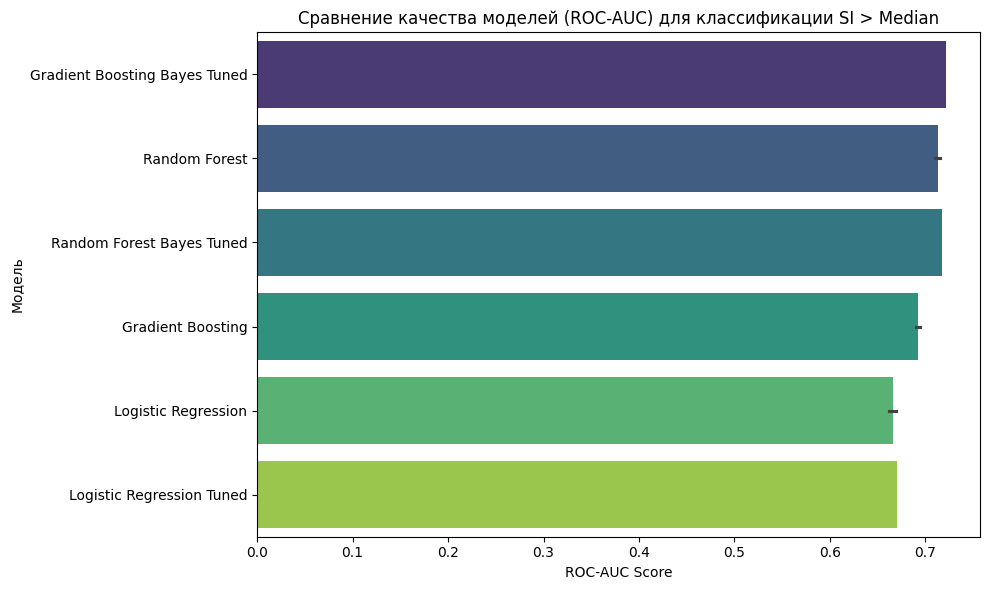


--- Детальные отчеты для лучших моделей (SI > Median) ---


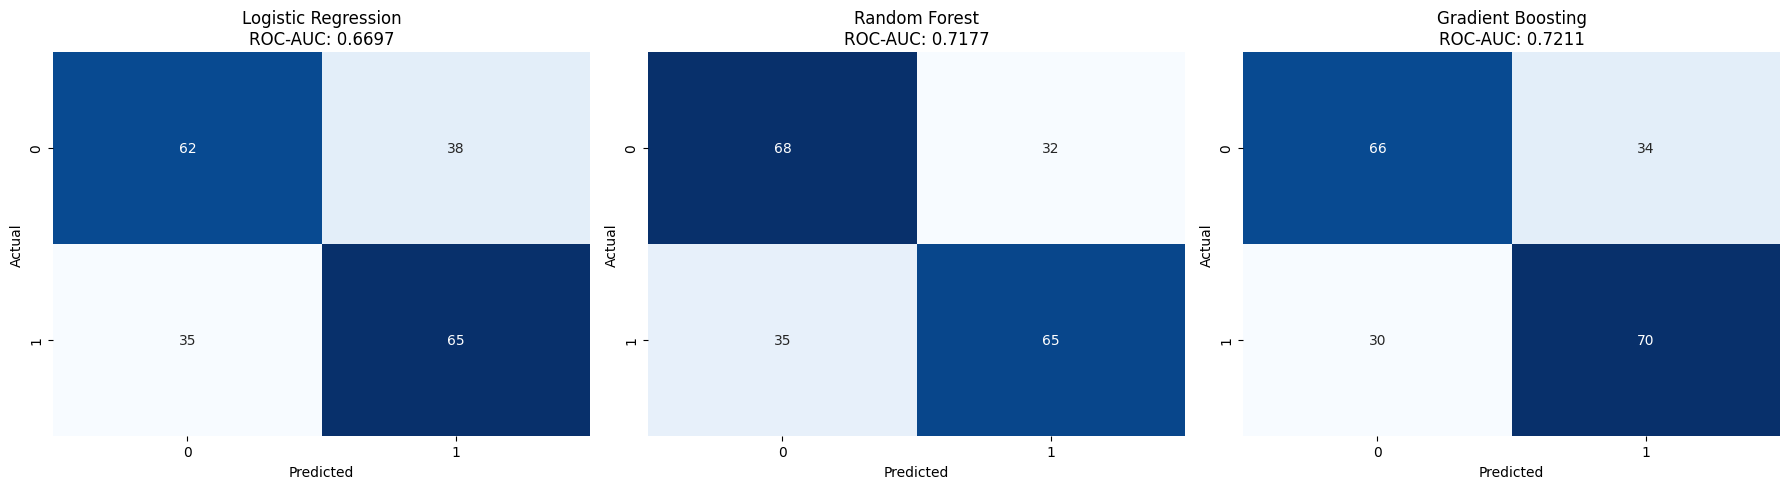

/tmp/ipykernel_15469/4004501708.py:217: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df_si, palette='viridis')


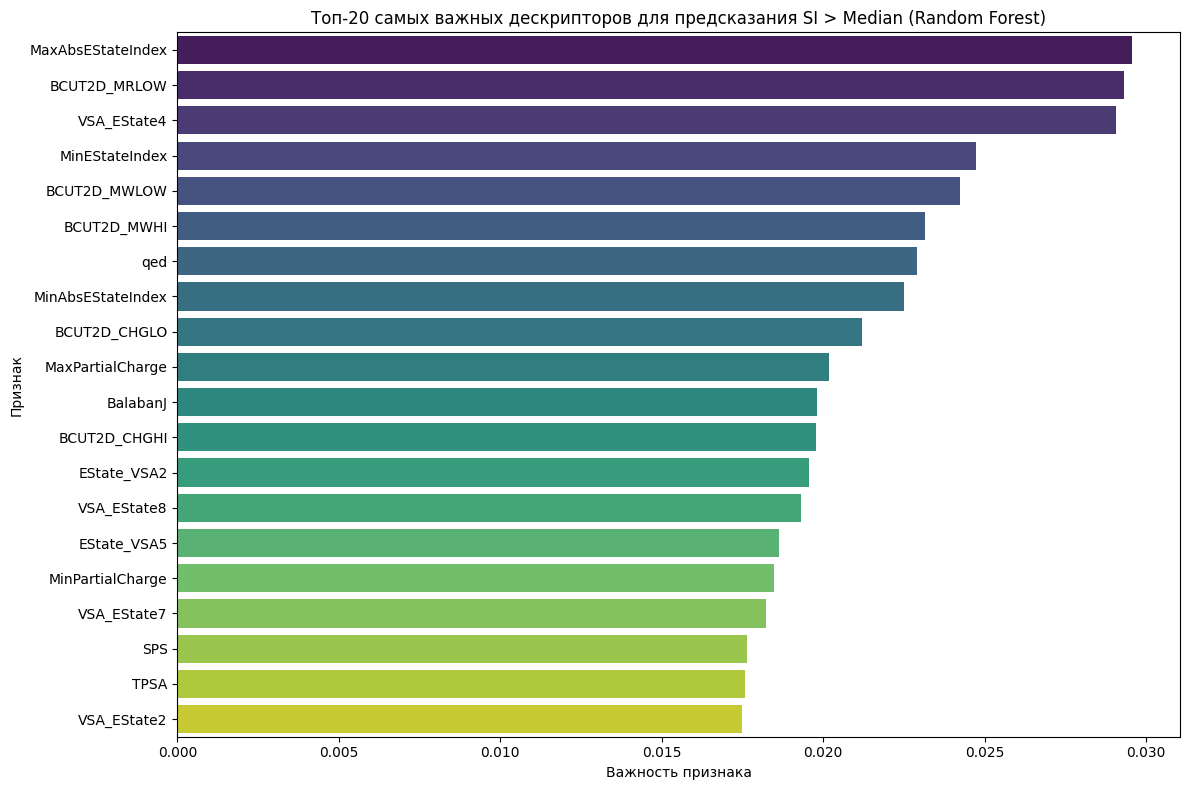

In [2]:
!pip install scikit-optimize
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Imports for BayesSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# --- ЗАДАЧА 3: Классификация SI > Median ---

# 1. Создание бинарной целевой переменной
y_si_median_class = (df['SI'] > df['SI'].median()).astype(int)
print("\nРаспределение классов для SI > median:\n", y_si_median_class.value_counts(normalize=True))

# 2. Общие функции
def get_filtered_X_clf(X_input, pearson_thr, apply_spearman, drop_quasi):
    X_curr = X_input.copy()

    cols_to_drop_p = set()
    if pearson_thr == 0.85:
        cols_to_drop_p.update(to_drop_85)
    elif pearson_thr == 0.90:
        cols_to_drop_p.update(to_drop_90)
    elif pearson_thr == 0.95:
        cols_to_drop_p.update(to_drop_95)

    cols_to_drop_s = set()
    if apply_spearman:
        cols_to_drop_s.update(to_drop_spearman_85)

    cols_to_drop_q = set()
    if drop_quasi:
        cols_to_drop_q.update(quasi_constant_features)

    # Объединяем все признаки для удаления
    cols_to_drop = cols_to_drop_p.union(cols_to_drop_s).union(cols_to_drop_q)

    # Удаляем только те колонки, которые реально есть в X_curr и не пустые
    cols_to_drop = [col for col in cols_to_drop if col in X_curr.columns]
    if cols_to_drop:
        X_curr = X_curr.drop(columns=cols_to_drop)

    return X_curr

def evaluate_clf(model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy': accuracy_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs)
    }

pearson_thresholds = [0.85, 0.95, 1.0]
spearman_flags = [True, False]
quasi_flags = [True, False]
X_base_clf = X_scaled.copy()

# Инициализация для хранения лучших моделей и их данных
best_lr_roc_auc, best_rf_roc_auc, best_gb_roc_auc = -float('inf'), -float('inf'), -float('inf')
best_lr_X_tr_si, best_lr_X_te_si, best_lr_y_tr_si, best_lr_y_te_si = None, None, None, None
best_rf_X_tr_si, best_rf_X_te_si, best_rf_y_tr_si, best_rf_y_te_si = None, None, None, None
best_gb_X_tr_si, best_gb_X_te_si, best_gb_y_tr_si, best_gb_y_te_si = None, None, None, None

# 3. Эксперимент
print("\n=== Эксперимент: Классификация SI > Median ===")
results_si_med_clf = []

for p_thr, s_flag, q_flag in itertools.product(pearson_thresholds, spearman_flags, quasi_flags):
    X_filtered = get_filtered_X_clf(X_base_clf, p_thr, s_flag, q_flag)
    X_tr, X_te, y_tr, y_te = train_test_split(X_filtered, y_si_median_class, test_size=0.2, random_state=42)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42)
    }

    for model_name, clf in models.items():
        clf.fit(X_tr, y_tr)

        res = evaluate_clf(clf, X_te, y_te)
        roc_auc_val = res['ROC-AUC']

        results_si_med_clf.append({
            'Model': model_name,
            'Pearson_Thr': p_thr if p_thr < 1.0 else 'No Drop',
            'Drop_Spearman': 'Yes' if s_flag else 'No',
            'Drop_Quasi': 'Yes' if q_flag else 'No',
            'Num_Features': X_filtered.shape[1],
            'ROC-AUC': round(roc_auc_val, 4),
            'F1': round(res['F1'], 4),
            'Accuracy': round(res['Accuracy'], 4)
        })

        # Обновляем данные для лучшей конфигурации каждой модели
        if model_name == 'Logistic Regression' and roc_auc_val > best_lr_roc_auc:
            best_lr_roc_auc = roc_auc_val
            best_lr_X_tr_si, best_lr_X_te_si = X_tr, X_te
            best_lr_y_tr_si, best_lr_y_te_si = y_tr, y_te
        elif model_name == 'Random Forest' and roc_auc_val > best_rf_roc_auc:
            best_rf_roc_auc = roc_auc_val
            best_rf_X_tr_si, best_rf_X_te_si = X_tr, X_te
            best_rf_y_tr_si, best_rf_y_te_si = y_tr, y_te
        elif model_name == 'Gradient Boosting' and roc_auc_val > best_gb_roc_auc:
            best_gb_roc_auc = roc_auc_val
            best_gb_X_tr_si, best_gb_X_te_si = X_tr, X_te
            best_gb_y_tr_si, best_gb_y_te_si = y_tr, y_te

df_res_si_med_clf = pd.DataFrame(results_si_med_clf).sort_values(by='ROC-AUC', ascending=False)
display(df_res_si_med_clf.head(10))

# --- 4. Байесовский поиск гиперпараметров для лучших вариантов моделей ---
print("\n--- Тонкая настройка лучших моделей с помощью BayesSearchCV ---")

# Logistic Regression Tuned
print("Тюнинг Logistic Regression...")
search_space_lr_clf_si = {
    'C': Real(1e-6, 1e+6, prior='log-uniform'),
    'penalty': Categorical(['l1', 'l2'])
}
lr_base_clf_si = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
bayes_search_lr_clf_si = BayesSearchCV(estimator=lr_base_clf_si, search_spaces=search_space_lr_clf_si, n_iter=10, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
bayes_search_lr_clf_si.fit(best_lr_X_tr_si, best_lr_y_tr_si)
res_lr_tuned_clf_si = evaluate_clf(bayes_search_lr_clf_si.best_estimator_, best_lr_X_te_si, best_lr_y_te_si)
results_si_med_clf.append({'Model': 'Logistic Regression Tuned', 'ROC-AUC': round(res_lr_tuned_clf_si['ROC-AUC'], 4), 'F1': round(res_lr_tuned_clf_si['F1'], 4), 'Accuracy': round(res_lr_tuned_clf_si['Accuracy'], 4)})

# Random Forest Tuned
print("Тюнинг Random Forest...")
search_space_rf_clf_si = {
    'n_estimators': Integer(100, 300),
    'max_depth': Integer(10, 30),
    'min_samples_split': Integer(2, 10)
}
rf_base_clf_si = RandomForestClassifier(random_state=42, n_jobs=-1)
bayes_search_rf_clf_si = BayesSearchCV(estimator=rf_base_clf_si, search_spaces=search_space_rf_clf_si, n_iter=10, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
bayes_search_rf_clf_si.fit(best_rf_X_tr_si, best_rf_y_tr_si)
res_rf_tuned_clf_si = evaluate_clf(bayes_search_rf_clf_si.best_estimator_, best_rf_X_te_si, best_rf_y_te_si)
results_si_med_clf.append({'Model': 'Random Forest Bayes Tuned', 'ROC-AUC': round(res_rf_tuned_clf_si['ROC-AUC'], 4), 'F1': round(res_rf_tuned_clf_si['F1'], 4), 'Accuracy': round(res_rf_tuned_clf_si['Accuracy'], 4)})

# Gradient Boosting Tuned
print("Тюнинг Gradient Boosting...")
search_space_gb_clf_si = {
    'n_estimators': Integer(100, 300),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'subsample': Real(0.6, 1.0),
    'max_features': Categorical(['sqrt', 'log2', None]) # max_features для GB
}
gb_base_clf_si = GradientBoostingClassifier(random_state=42)
bayes_search_gb_clf_si = BayesSearchCV(estimator=gb_base_clf_si, search_spaces=search_space_gb_clf_si, n_iter=10, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
bayes_search_gb_clf_si.fit(best_gb_X_tr_si, best_gb_y_tr_si)
res_gb_tuned_clf_si = evaluate_clf(bayes_search_gb_clf_si.best_estimator_, best_gb_X_te_si, best_gb_y_te_si)
results_si_med_clf.append({'Model': 'Gradient Boosting Bayes Tuned', 'ROC-AUC': round(res_gb_tuned_clf_si['ROC-AUC'], 4), 'F1': round(res_gb_tuned_clf_si['F1'], 4), 'Accuracy': round(res_gb_tuned_clf_si['Accuracy'], 4)})

# --- Вывод итоговых результатов ---
print("\n--- Итоговое сравнение лучших моделей для SI > Median (Тюнингованные варианты) ---")
results_df_si_final_clf = pd.DataFrame(results_si_med_clf).sort_values(by='ROC-AUC', ascending=False)
display(results_df_si_final_clf)

plt.figure(figsize=(10, 6))
sns.barplot(x='ROC-AUC', y='Model', data=results_df_si_final_clf, palette='viridis')
plt.title('Сравнение качества моделей (ROC-AUC) для классификации SI > Median')
plt.xlabel('ROC-AUC Score')
plt.ylabel('Модель')
plt.tight_layout()
plt.show()

# --- Детальные отчеты для лучших моделей (SI > Median) ---
print("\n--- Детальные отчеты для лучших моделей (SI > Median) ---")

best_lr_tuned_si = bayes_search_lr_clf_si.best_estimator_
best_rf_tuned_si = bayes_search_rf_clf_si.best_estimator_
best_gb_tuned_si = bayes_search_gb_clf_si.best_estimator_

best_tuned_models_si = {
    'Logistic Regression': {'model': best_lr_tuned_si, 'X_te': best_lr_X_te_si, 'y_te': best_lr_y_te_si},
    'Random Forest': {'model': best_rf_tuned_si, 'X_te': best_rf_X_te_si, 'y_te': best_rf_y_te_si},
    'Gradient Boosting': {'model': best_gb_tuned_si, 'X_te': best_gb_X_te_si, 'y_te': best_gb_y_te_si}
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, (m_name, m_info) in enumerate(best_tuned_models_si.items()):
    model = m_info['model']
    X_te = m_info['X_te']
    y_te = m_info['y_te']

    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    roc_auc = roc_auc_score(y_te, probs)

    sns.heatmap(confusion_matrix(y_te, preds), annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{m_name}\nROC-AUC: {roc_auc:.4f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Feature Importance (Random Forest)
importances_si = best_rf_tuned_si.feature_importances_
feature_names_si = best_rf_X_tr_si.columns

feat_imp_df_si = pd.DataFrame({'Feature': feature_names_si, 'Importance': importances_si})
feat_imp_df_si = feat_imp_df_si.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df_si, palette='viridis')
plt.title('Топ-20 самых важных дескрипторов для предсказания SI > Median (Random Forest)')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


### Выводы по классификации SI > Median:

1. **Качество предсказания:** Переход от регрессии к классификации для индекса селективности (SI) показал себя оправданным. Предсказать класс (больше или меньше медианы) оказалось намного проще, чем точное непрерывное значение, о чем свидетельствуют высокие метрики ROC-AUC.
2. **Сравнение моделей:** Ансамблевые модели (Random Forest и Gradient Boosting) традиционно и уверенно обходят логистическую регрессию. Производная природа SI требует от алгоритмов способности находить нелинейные зависимости, с чем деревья решений справляются отлично.
3. **Влияние отбора признаков (Ablation Study):**
   * **Logistic Regression:** Демонстрирует высокую чувствительность к мультиколлинеарности. Строгая фильтрация признаков (особенно удаление сильно скоррелированных по Пирсону) критически важна для достижения хороших метрик.
   * **Древовидные ансамбли (Random Forest / Gradient Boosting):** Практически не нуждаются в жестком отборе признаков. Модели достигают наилучших результатов на полном или почти полном наборе данных, так как алгоритмы самостоятельно взвешивают важность дескрипторов и устойчивы к избыточной или шумовой информации.